In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import matplotlib.ticker as ticker

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Carregamento do Dataset Mestre
df = pd.read_csv('database_completo_varejo.csv', parse_dates=['data_pedido', 'data_nascimento'])

print(f"Dataset carregado: {df.shape[0]} registros prontos para análise.")
df.head()

Dataset carregado: 10 registros prontos para análise.


,pedido_id,data_pedido,valor_venda,cliente_id,nome_completo,data_nascimento,geracao,nome,categoria_produto,endereco_entrega,latitude,longitude
0,11,2024-01-10,250.5,1,José Noli,2002-04-26,Gen Z,Teclado Mecânico Gamer RGB,Periféricos,"Rua das Flores, 123",-46.6333,-23.5505
1,12,2024-01-12,120.0,2,Maria Oliveira,1995-08-12,Millennials,Mouse Gamer Óptico Ultraleve,Periféricos,"Av. Paulista, 1500",-43.1729,-22.9068
2,13,2024-01-15,890.9,3,Carlos Drummond,1980-10-30,Gen X,Headset Gamer Surround 7.1,Periféricos,"Rua Bahia, 45",-43.9345,-19.9167
3,14,2024-01-20,45.0,4,Ana Beatriz,2005-01-15,Gen Z,Teclado Mecânico Gamer RGB,Periféricos,"Praça da Sé, 10",-49.2671,-25.4290
4,15,2024-01-25,1500.0,5,Ricardo Santos,1992-11-22,Millennials,Placa de Vídeo RTX 4070 Ti SUPER,Hardware Interno,"Rua do Ouvidor, 100",-51.2177,-30.0346


In [2]:
'''
usuario = "root"          
senha = "***********"
host = "localhost"        
banco = "retail_db"
'''

try:
    engine = create_engine(f"mysql+mysqlconnector://{usuario}:{senha}@{host}/{banco}")
    
    with engine.connect() as connection:
        result = connection.execute(text("SELECT 'Conexão OK'"))
        print(f" {result.fetchone()[0]}: Conectado ao banco '{banco}'!")
        
except Exception as e:
    print(f" Erro ao conectar: {e}")

 Erro ao conectar: name 'create_engine' is not defined


In [ ]:
mapa_brasil.save('mapa_calor_vendas.html')
print("Mapa salvo como 'mapa_calor_vendas.html'. Abra este arquivo na sua pasta para visualizar!")

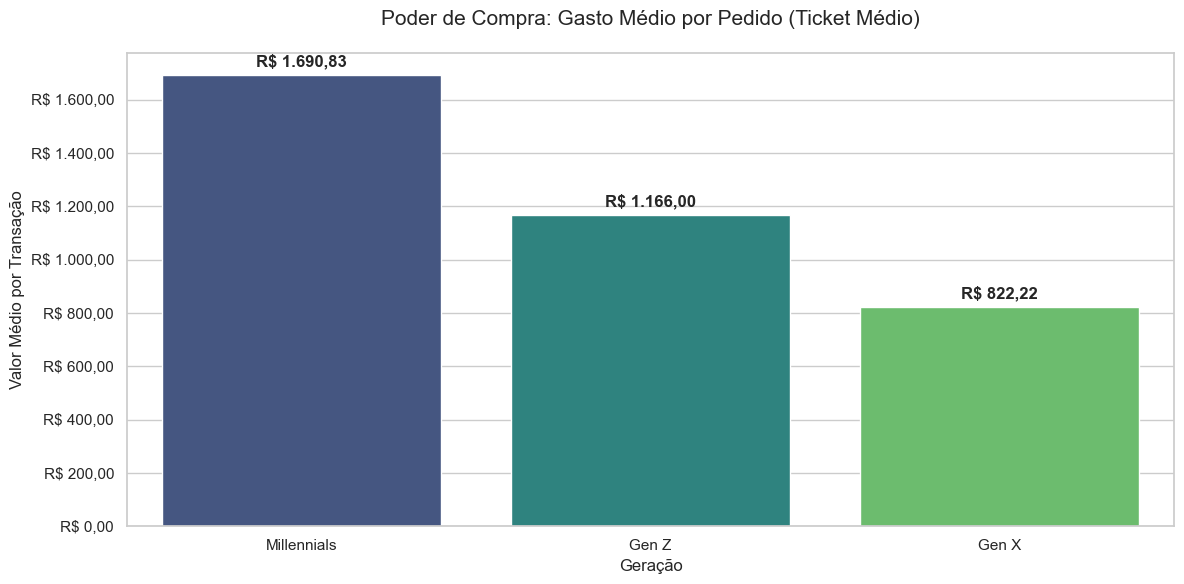

✅ Insight de renda finalizado com sucesso!


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

query_renda_corrigida = """
    SELECT 
        CASE 
            WHEN (YEAR(CURDATE()) - YEAR(c.data_nascimento)) <= 25 THEN 'Gen Z'
            WHEN (YEAR(CURDATE()) - YEAR(c.data_nascimento)) BETWEEN 26 AND 41 THEN 'Millennials'
            WHEN (YEAR(CURDATE()) - YEAR(c.data_nascimento)) BETWEEN 42 AND 57 THEN 'Gen X'
            ELSE 'Boomers'
        END AS geracao,
        AVG(p.valor) as ticket_medio
    FROM pedidos p
    JOIN clientes c ON p.cliente_id = c.cliente_id
    GROUP BY geracao
    ORDER BY ticket_medio DESC
"""

try:
    df_renda = pd.read_sql(query_renda_corrigida, engine)

    
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    ax = sns.barplot(
        data=df_renda, 
        x='geracao', 
        y='ticket_medio', 
        palette='viridis',
        hue='geracao',
        legend=False
    )

    
    def formata_real(x, pos):
        return f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(formata_real))

    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(formata_real(height, None), 
                   (p.get_x() + p.get_width() / 2., height), 
                   ha='center', va='center', 
                   xytext=(0, 10), 
                   textcoords='offset points',
                   fontweight='bold')

    plt.title('Poder de Compra: Gasto Médio por Pedido (Ticket Médio)', fontsize=15, pad=20)
    plt.xlabel('Geração', fontsize=12)
    plt.ylabel('Valor Médio por Transação', fontsize=12)
    
    plt.tight_layout()
    plt.show()

    print("Insight de renda finalizado com sucesso!")

except Exception as e:
    print(f"Erro: {e}")

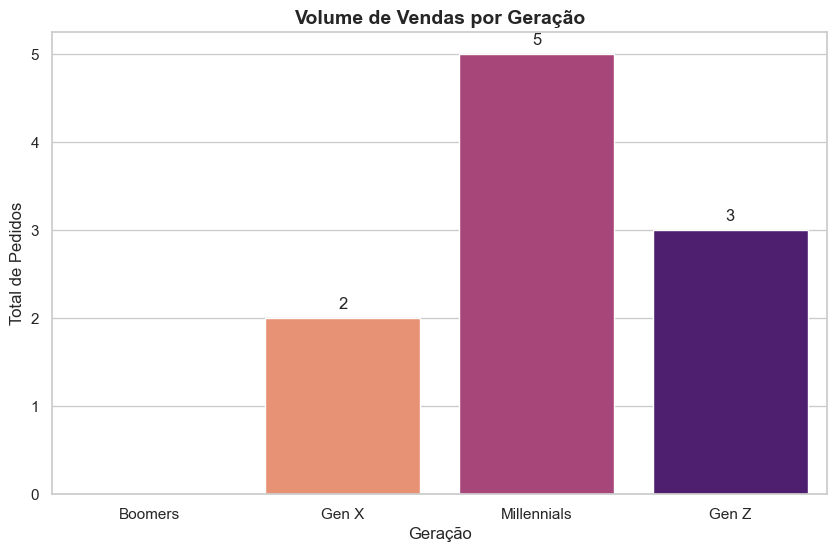

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('database_completo_varejo.csv')
ordem = ['Boomers', 'Gen X', 'Millennials', 'Gen Z']

if 'geracao' in df.columns:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df, x='geracao', order=ordem, palette='magma', hue='geracao', legend=False)
    
    plt.title('Volume de Vendas por Geração', fontsize=14, fontweight='bold')
    plt.xlabel('Geração')
    plt.ylabel('Total de Pedidos')
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')
    plt.show()
else:
    print(f" Erro: A coluna 'geracao' não foi encontrada. As colunas disponíveis são: {list(df.columns)}")

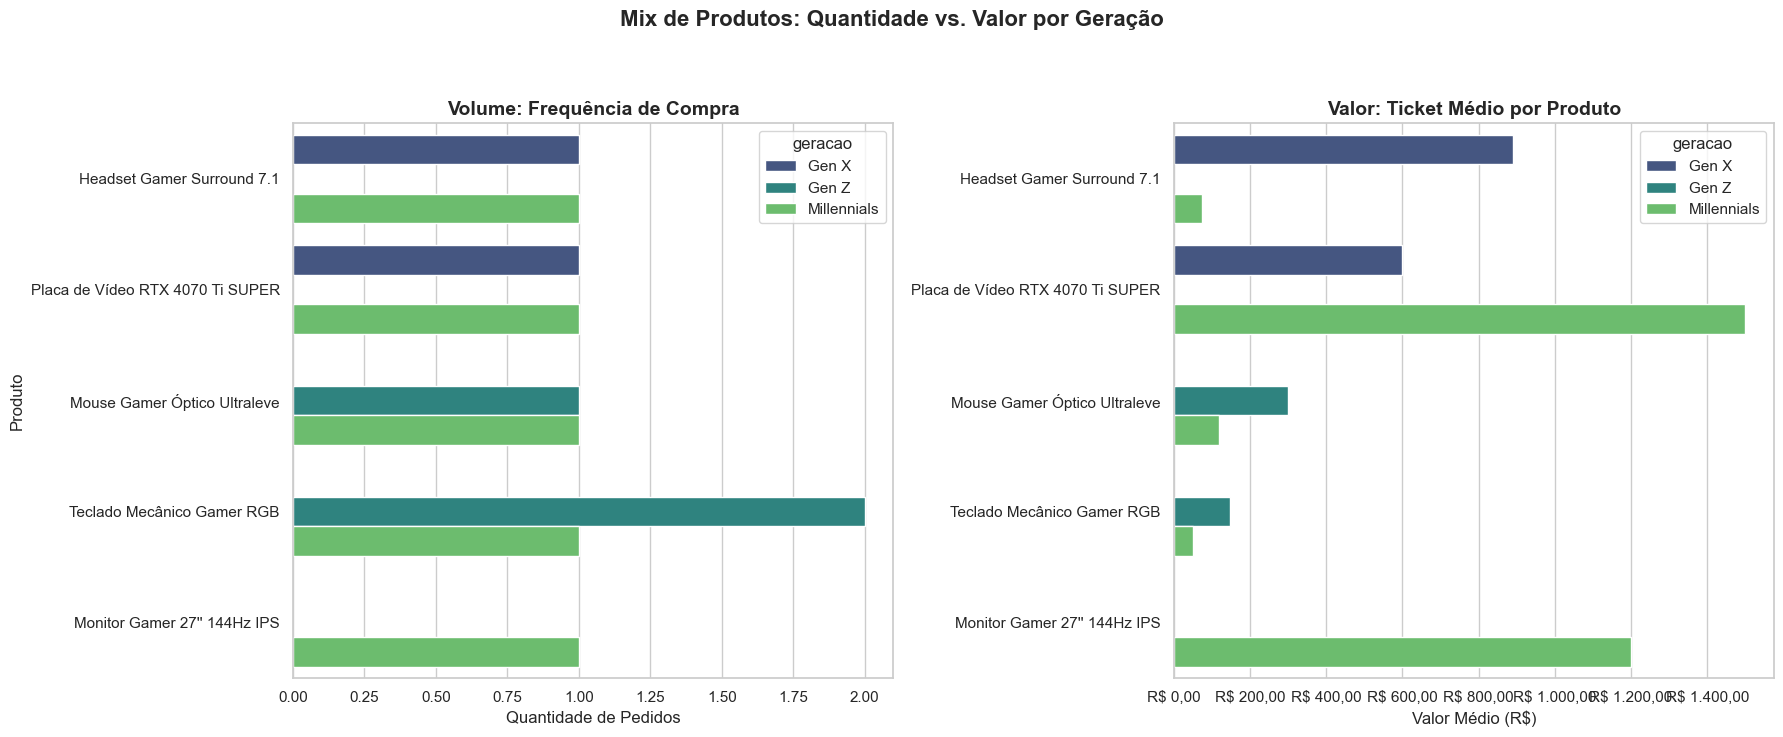

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df_prod_geracao = df.groupby(['geracao', 'nome']).agg({
    'pedido_id': 'count',
    'valor_venda': 'mean'
}).reset_index()

geracoes_foco = ['Gen Z', 'Millennials', 'Gen X']
df_filtrado = df_prod_geracao[df_prod_geracao['geracao'].isin(geracoes_foco)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=df_filtrado, x='pedido_id', y='nome', hue='geracao', ax=ax1, palette='viridis')
ax1.set_title('Volume: Frequência de Compra', fontsize=14, fontweight='bold')
ax1.set_xlabel('Quantidade de Pedidos')
ax1.set_ylabel('Produto')

sns.barplot(data=df_filtrado, x='valor_venda', y='nome', hue='geracao', ax=ax2, palette='viridis')
ax2.set_title('Valor: Ticket Médio por Produto', fontsize=14, fontweight='bold')
ax2.set_xlabel('Valor Médio (R$)')
ax2.set_ylabel('')

formatter = ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))
ax2.xaxis.set_major_formatter(formatter)

plt.suptitle('Mix de Produtos: Quantidade vs. Valor por Geração', fontsize=16, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

Análise Estratégica e Insights de Negócio
Baseado nos gráficos gerados através da base de dados sintéticos, podemos observar que:

1. Distribuição Geográfica e Contexto Socioeconômico
A Unidade Federativa (UF) com maior frequência de pedidos é o Rio Grande do Sul (RS), com concentração significativa em Porto Alegre. Baseado em questões socioeconômicas, o Rio Grande do Sul apresenta um PIB per capita elevado devido a uma combinação de estrutura econômica diversificada, baixa densidade demográfica em relação ao volume de riqueza gerada e a presença de setores de alta produtividade.

2. Análise de Gasto Médio e Perfil Etário
Os Millennials possuem o maior valor médio de ticket. Este dado é coerente com o perfil demográfico: indivíduos nascidos entre 1981 e 1996 possuem hoje uma média de idade entre 29 e 45 anos. Economicamente, estudos apontam que o teto salarial de um profissional no Brasil tende a se consolidar após os 30 anos, o que justifica a liderança da Geração Y neste índice de consumo. 

3. Volume de Vendas e Poder de Compra
Justamente pelo maior poder de compra acumulado, a análise de transações demonstra que a Geração Y (Millennials) encabeça o volume total de vendas.

Sugestão Estratégica
Como os Millennials são os maiores consumidores, impulsionados por fatores socioeconômicos, é necessário realizar testes com produtos Premium para análise de recepção mercadológica e alavancagem de margem. Vale ressaltar que, embora a Geração Y possua o maior número de vendas, eles não são necessariamente os que consomem os produtos mais caros; esse comportamento de compra de itens de alto valor unitário (Premium) é mais acentuado na Geração X.